In [1]:
# pip install pytesseract

In [2]:
TESS_CONFIG = "--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"


In [3]:
# pip install easyocr

In [4]:
import cv2
import numpy as np
import pytesseract
import re
from ultralytics import YOLO
from PIL import Image, ExifTags
from collections import Counter
import cv2
import torch
import easyocr

## Auto-Orientation (Paper: Auto-orientation via EXIF)

In [5]:
def auto_orient(image_bgr):
    try:
        img = Image.fromarray(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        exif = img._getexif()
        if exif is not None:
            for k, v in ExifTags.TAGS.items():
                if v == "Orientation":
                    orientation_key = k
                    break
            orientation = exif.get(orientation_key, None)

            if orientation == 3:
                img = img.rotate(180, expand=True)
            elif orientation == 6:
                img = img.rotate(270, expand=True)
            elif orientation == 8:
                img = img.rotate(90, expand=True)

        return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    except:
        return image_bgr


## Strong OCR Preprocessing (Paper-Faithful + Adaptive Median Filter)

In [6]:
def preprocess_plate_for_ocr(plate):
    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

    # Adaptive median filtering (night / rain)
    gray = cv2.medianBlur(gray, 5)

    # CLAHE for local contrast
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # Adaptive threshold (key for video)
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 15
    )

    # Sharpen edges
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    thresh = cv2.filter2D(thresh, -1, kernel)

    return thresh


## OCR + Indian Regex Validation

In [ ]:
TESS_CONFIG = r'--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

def ocr_plate(plate_img):
    text = pytesseract.image_to_string(plate_img, config=TESS_CONFIG)
    return text.strip().replace(" ", "").replace("\n", "")

import easyocr

# def ocr_plate(plate_img):
#     # Initialize the EasyOCR reader (this can be done outside the function for efficiency)
#     reader = easyocr.Reader(['en'])  # Specify the language(s) you want to use
#     results = reader.readtext(plate_img)  # Read text from the image
    
#     # Extract and format the detected text
#     text = ""
#     for (bbox, text_detected, prob) in results:
#         text += text_detected + " "  # Concatenate detected text with a space

    # Clean up the text
    # return text.strip().replace(" ", "").replace("\n", "")


# def validate_indian_plate(text):
#     pattern = r'^[A-Z]{2}[0-9]{1,2}[A-Z]{1,2}[0-9]{4}$'
#     return re.match(pattern, text) is not None


In [8]:
import re

def validate_indian_plate(text):
    if not text:
        return False

    # Normalize OCR text
    text = re.sub(r'[^A-Z0-9]', '', text.upper())

    # Character confusion maps
    DIGIT_TO_ALPHA = {
        '0': 'O', '1': 'I', '2': 'Z', '3': 'B', '4': 'A',
        '5': 'S', '6': 'G', '7': 'T', '8': 'B', '9': 'G'
    }

    ALPHA_TO_DIGIT = {
        'O': '0', 'Q': '0',
        'I': '1', 'L': '1',
        'Z': '2',
        'S': '5',
        'B': '8',
        'G': '6',
        'T': '7',
        'A': '4'
    }

    def to_alpha(c):
        return DIGIT_TO_ALPHA.get(c, c)

    def to_digit(c):
        return ALPHA_TO_DIGIT.get(c, c)

    # ---------------- FORMAT: AA12A1234 ----------------
    if len(text) == 9:
        s = list(text)

        # First two alphabets (state)
        s[0] = to_alpha(s[0])
        s[1] = to_alpha(s[1])

        # Next two digits (RTO)
        s[2] = to_digit(s[2])
        s[3] = to_digit(s[3])

        # Series (1 alphabet)
        s[4] = to_alpha(s[4])

        # Last 4 digits
        for i in range(5, 9):
            s[i] = to_digit(s[i])

        corrected = ''.join(s)
        return bool(re.match(r'^[A-Z]{2}[0-9]{2}[A-Z]{1}[0-9]{4}$', corrected))

    # ---------------- FORMAT: AA12AA1234 ----------------
    if len(text) == 10:
        s = list(text)

        # First two alphabets (state)
        s[0] = to_alpha(s[0])
        s[1] = to_alpha(s[1])

        # Next two digits (RTO)
        s[2] = to_digit(s[2])
        s[3] = to_digit(s[3])

        # Series (2 alphabets)
        s[4] = to_alpha(s[4])
        s[5] = to_alpha(s[5])

        # Last 4 digits
        for i in range(6, 10):
            s[i] = to_digit(s[i])

        corrected = ''.join(s)
        return bool(re.match(r'^[A-Z]{2}[0-9]{2}[A-Z]{2}[0-9]{4}$', corrected))

    return False


## Temporal OCR Voting (Paper: Temporal Filtering)

In [9]:
def temporal_vote(ocr_list):
    valid = [t for t in ocr_list if validate_indian_plate(t)]
    if not valid:
        return None
    return Counter(valid).most_common(1)[0][0]


In [10]:
def normalize_plate_text(text):
    text = text.upper()
    text = text.replace(" ", "")
    text = text.replace("-", "")
    text = text.replace(".", "")
    
    # common OCR confusions
    text = text.replace("O", "0")
    text = text.replace("I", "1")
    text = text.replace("Z", "2")
    text = text.replace("S", "5")
    
    return text


## End-to-End Plate Accuracy Evaluation (%)

In [11]:
# ground_truth = [
#     "MH02EK4399",
#     "DL8CAF1234",
#     "UP32AB9999"
# ]


# correct = 0
# total = min(len(final_predictions), len(ground_truth))

# for pred, gt in zip(final_predictions, ground_truth):
#     if pred == gt:
#         correct += 1

# accuracy = (correct / total) * 100 if total > 0 else 0
# print(f"End-to-End Plate Recognition Accuracy: {accuracy:.2f}%")


## END-TO-END VIDEO PIPELINE

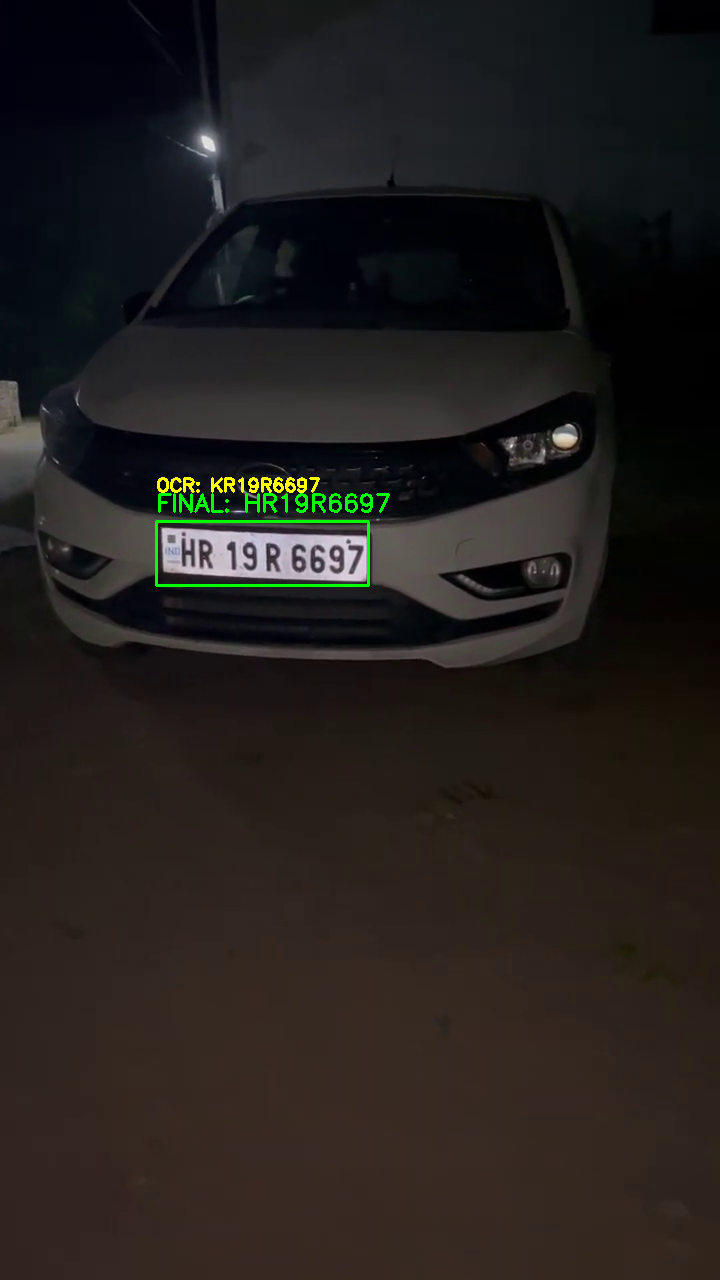

🛑 Stopped by user (Ctrl + C pressed)
✅ Video released cleanly


In [12]:
from ultralytics import YOLO
import cv2
from collections import deque
from IPython.display import display, clear_output
from PIL import Image

# ---------------- LOAD MODEL ----------------
model = YOLO(
    r"D:\Automatic ANPR\Self_Code\runs\detect\lp_yolov8s_stage2_final3\weights\best.pt"
)

# ---------------- VIDEO ----------------
video_path = r"C:\Users\100ra\Downloads\How_High_Security_Number_Plate_challan_system_identifies_car_for_making_challan_digitalautomobile_720P.mp4"
cap = cv2.VideoCapture(video_path)

plate_buffer = deque(maxlen=7)
final_plate = None

try:
    # ---------------- MAIN LOOP ----------------
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = auto_orient(frame)
        results = model(frame, conf=0.4, verbose=False)

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                plate_crop = frame[y1:y2, x1:x2]

                proc = preprocess_plate_for_ocr(plate_crop)
                text = ocr_plate(proc)

                if text:
                    print("OCR:", text)

                if validate_indian_plate(text):
                    plate_buffer.append(text)

                if len(plate_buffer) >= 5:
                    final_plate = temporal_vote(list(plate_buffer))

                # Draw box
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

                if text:
                    cv2.putText(
                        frame,
                        f"OCR: {text}",
                        (x1, y1 - 30),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (0, 255, 255),
                        2
                    )

                if final_plate:
                    cv2.putText(
                        frame,
                        f"FINAL: {final_plate}",
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8,
                        (0, 255, 0),
                        2
                    )

        # ---------------- NOTEBOOK DISPLAY ----------------
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        display(Image.fromarray(rgb))

except KeyboardInterrupt:
    print("🛑 Stopped by user (Ctrl + C pressed)")

finally:
    cap.release()
    print("✅ Video released cleanly")


In [13]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import deque

model = YOLO(
    r"D:\Automatic ANPR\Self_Code\runs\detect\lp_yolov8s_stage2_final3\weights\best.pt"
)


## IMAGE-BASED ANPR PIPELINE (Single Image)


0: 640x480 1 license_plate, 202.6ms
Speed: 42.7ms preprocess, 202.6ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 480)


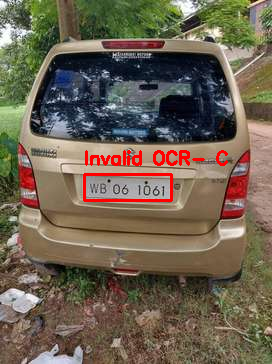

In [15]:
img_path = r"D:\Automatic ANPR\Self_Code\dataset_original\images\train\WB19.jpg"
img = cv2.imread(img_path)

img = auto_orient(img)

results = model(img, conf=0.4)

for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        plate_crop = img[y1:y2, x1:x2]

        proc = preprocess_plate_for_ocr(plate_crop)
        text = ocr_plate(proc)

        if validate_indian_plate(text):
            label = f"Plate: {text}"
            color = (0, 255, 0)
        else:
            label = f"Invalid OCR- {text}"
            color = (0, 0, 255)

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            img, label, (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2
        )

# 👇 NOTEBOOK DISPLAY (instead of cv2.imshow)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
display(Image.fromarray(rgb))


## REAL-TIME WEBCAM ANPR PIPELINE (Live Demo)

In [ ]:
import cv2
from collections import deque
from IPython.display import display, clear_output
from PIL import Image

cap = cv2.VideoCapture(0)

plate_buffer = deque(maxlen=7)
final_plate = None

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = auto_orient(frame)
        results = model(frame, conf=0.4)

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                plate_crop = frame[y1:y2, x1:x2]

                proc = preprocess_plate_for_ocr(plate_crop)
                text = ocr_plate(proc)

                if validate_indian_plate(text):
                    plate_buffer.append(text)

                if len(plate_buffer) >= 5:
                    final_plate = temporal_vote(list(plate_buffer))

                cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)

                if final_plate:
                    cv2.putText(
                        frame, final_plate,
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7, (0,255,0), 2
                    )

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        clear_output(wait=True)
        display(Image.fromarray(rgb))

except KeyboardInterrupt:
    print("🛑 Stopped by user (key pressed)")

finally:
    cap.release()
    print("✅ Camera released cleanly")


🛑 Stopped by user (key pressed)
✅ Camera released cleanly


# Fun

Plate: WB061Q61 | Confidence: 0.31


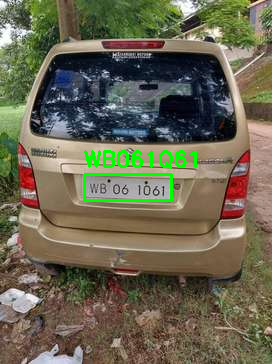

In [16]:
import cv2
import torch
import easyocr
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

# Load YOLOv8 model
model = YOLO(
    r'D:\Automatic ANPR\Self_Code\runs\detect\lp_yolov8s_stage2_final3\weights\best.pt'
)

# Initialize EasyOCR
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

def preprocess_plate(plate):
    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 11, 17, 17)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
    return thresh

def recognize_number_plate(frame):
    results = model(frame, conf=0.4, verbose=False)

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            plate = frame[y1:y2, x1:x2]
            if plate.size == 0:
                continue

            processed_plate = preprocess_plate(plate)
            ocr_result = reader.readtext(processed_plate)

            for (_, text, prob) in ocr_result:
                text = text.replace(" ", "").upper()
                print(f"Plate: {text} | Confidence: {prob:.2f}")

                cv2.rectangle(frame, (x1, y1), (x2, y2),
                              (0, 255, 0), 2)
                cv2.putText(frame, text,
                            (x1, y1 - 8),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, (0, 255, 0), 2)

    return frame

# ---------------- IMAGE INFERENCE (NOTEBOOK SAFE) ----------------
img_path = r"D:\Automatic ANPR\Self_Code\dataset_original\images\train\WB19.jpg"
img = cv2.imread(img_path)

processed_img = recognize_number_plate(img)

# 👇 Display below the cell instead of cv2.imshow
rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)
display(Image.fromarray(rgb))
